# Laboratório 12: Escalonamento e Desbalanceamento (SMOTE)
**Disciplina:** Extração e Preparação de Dados (IBM8915)  
**Tópico:** A Matemática das Distâncias e o Paradigma do Desbalanceamento

Neste laboratório, simularemos um problema clássico de Risco de Crédito: identificar fraudes em um cenário onde elas representam apenas 1% dos dados. Vamos abordar dois problemas:
1. **Escalonamento:** Evitar que variáveis com grandezas maiores esmaguem dados com grandezas menores no cálculo de distâncias.
2. **Desbalanceamento:** Evitar a "armadilha da acurácia", onde o modelo pode simplesmente chutar "não-fraude" e alcançar 99% de acerto sem aprender o padrão da classe rara.\

### 0. Preparação do Ambiente e Criação dos Dados
Vamos importar as bibliotecas e gerar um dataset sintético para o nosso estudo simulando *10.000 transações*, onde **apenas 1% são fraudes**.\

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Instale o imbalanced-learn se necessário: !pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# Gerando um dataset sintético desbalanceado
# 2 features para facilitar visualização, 1% de fraude (classe 1)
X, y = make_classification(n_samples=10000, n_features=2, n_redundant=0, 
                           n_clusters_per_class=1, weights=[0.99], random_state=42)

# Simulando diferença de grandezas para justificar o escalonamento
# Ex: Feature 0 é Salário (multiplicado por 10000), Feature 1 é Número de Filhos (dividido por 10)
X[:, 0] = X[:, 0] * 10000 + 50000 
X[:, 1] = np.abs(X[:, 1] / 10)

df = pd.DataFrame(X, columns=['Salario', 'Num_Filhos'])
df['Fraude'] = y

print("Distribuição original (Fraudes vs Normais):")
print(df['Fraude'].value_counts(normalize=True))
df.head()

Distribuição original (Fraudes vs Normais):
Fraude
0    0.9859
1    0.0141
Name: proportion, dtype: float64


,Salario,Num_Filhos,Fraude
0,52047.603230,0.035767,0
1,36188.030158,0.139004,0
2,55562.027602,0.069167,0
3,24675.245058,0.204337,0
4,52306.472815,0.034490,0


---
### Missão 1: Split Seguro
Antes de realizarmos qualquer transformação nos dados, devemos isolar `X` e `y` e dividir a base em partes de **Treino** (conhecimento passado) e **Teste** (validação futura).

Isso nos protegerá do terrível ***Data Leakage*** (Vazamento de Dados).\

In [2]:
# Separando features do alvo
X_dados = df[['Salario', 'Num_Filhos']]
y_dados = df['Fraude']

# Dividindo 80% treino e 20% teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X_dados, y_dados, test_size=0.20, random_state=42, stratify=y_dados)

print(f"Treino: {X_treino.shape[0]} amostras")
print(f"Teste: {X_teste.shape[0]} amostras")

Treino: 8000 amostras
Teste: 2000 amostras


---
### Missão 2: Escala (Feature Scaling)
O algoritmo não sabe que 'Salário' e 'Num_Filhos' têm naturezas diferentes. Por isso, a grandeza exorbitante do Salário definirá sozinha os cálculos de distância.

Sua missão é usar o **`StandardScaler`** para padronizar as features (Média 0 e Desvio Padrão 1).

**⚠️ ATENÇÃO - Regra de Ouro:**
*   Use `.fit_transform()` no **Treino**.
*   Use apenas `.transform()` no **Teste**.\

In [3]:
# Instanciando o padronizador
scaler_std = StandardScaler()

# O Treino ensina a régua estatística (fit) e já é transformado
X_treino_escalonado = scaler_std.fit_transform(X_treino)

# O Teste apanha a régua estatística aprendida no passado e sofre a transformação
X_teste_escalonado = scaler_std.transform(X_teste)

# Voltando para Pandas DataFrame apenas para visualização
X_treino_scaled_df = pd.DataFrame(X_treino_escalonado, columns=['Salario', 'Num_Filhos'])

print("Média das features escalonadas (Próximo a ZERO):")
print(X_treino_scaled_df.mean().round(2))
print("\nDesvio padrão escalonado (Igual a UM):")
print(X_treino_scaled_df.std().round(2))

Média das features escalonadas (Próximo a ZERO):
Salario       0.0
Num_Filhos   -0.0
dtype: float64

Desvio padrão escalonado (Igual a UM):
Salario       1.0
Num_Filhos    1.0
dtype: float64


#### Visualizando o Impacto do Escalonamento
Vamos observar geometricamente como a padronização não afeta a distribuição dos dados, mas sim a *escala* em que eles são representados.\

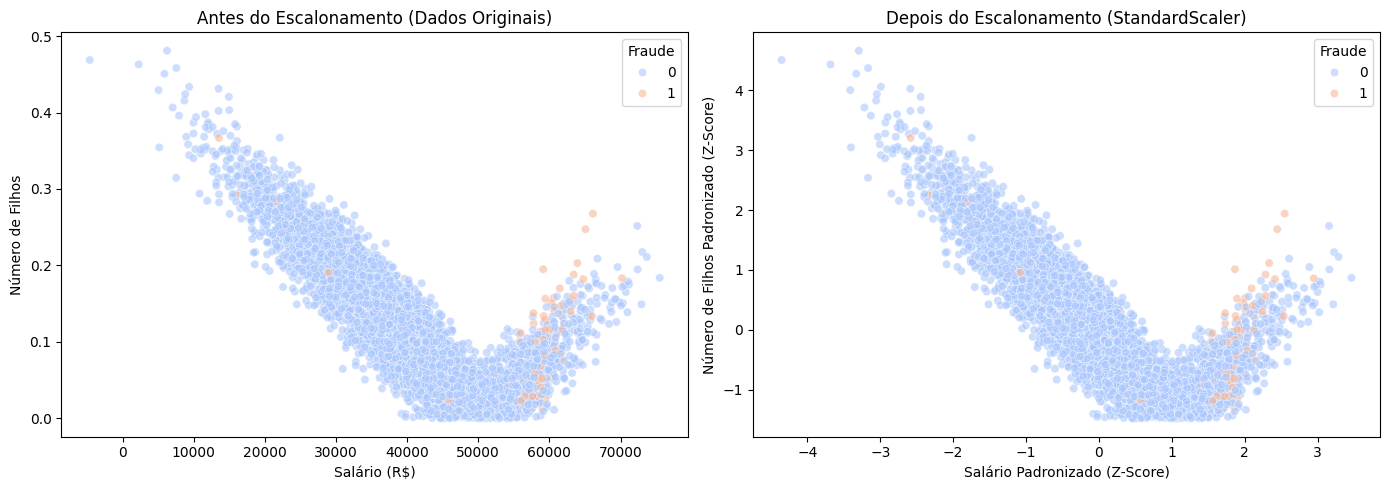

In [4]:
# Gráfico Comparativo: Antes e Depois da Padronização
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Dados Originais (Treino)
sns.scatterplot(x=X_treino['Salario'], y=X_treino['Num_Filhos'], hue=y_treino, palette='coolwarm', alpha=0.6, ax=ax[0])
ax[0].set_title('Antes do Escalonamento (Dados Originais)')
ax[0].set_xlabel('Salário (R$)')
ax[0].set_ylabel('Número de Filhos')

# Gráfico 2: Dados Padronizados (Treino)
sns.scatterplot(x=X_treino_scaled_df['Salario'], y=X_treino_scaled_df['Num_Filhos'], hue=y_treino.reset_index(drop=True), palette='coolwarm', alpha=0.6, ax=ax[1])
ax[1].set_title('Depois do Escalonamento (StandardScaler)')
ax[1].set_xlabel('Salário Padronizado (Z-Score)')
ax[1].set_ylabel('Número de Filhos Padronizado (Z-Score)')

plt.tight_layout()
plt.show()

---
### Missão 3: Equilíbrio (A Cirurgia Sintética com SMOTE)
Se fôssemos treinar nosso modelo agora, a precisão na classe `0 (Normal)` seria altíssima, e a classe `1 (Fraude)` seria ignorada, devido à sua presença de `1%` na base.

Vamos acionar o *Synthetic Minority Over-sampling TEchnique* (**SMOTE**) da biblioteca `imbalanced-learn` para gerar sinteticamente novas ocorrências da classe minoritária dentro do espaço geométrico.\

In [5]:
# 1. Instanciando o gerador sintético (analisando os 5 vizinhos mais próximos)
smote = SMOTE(k_neighbors=5, random_state=42)

# 2. Gerando novas fraudes artificiais APENAS NO TREINO para não contaminar o teste
X_treino_balanceado, y_treino_balanceado = smote.fit_resample(X_treino_escalonado, y_treino)

print("--- Antes do SMOTE no Treino ---")
print(y_treino.value_counts())

print("\n--- Depois do SMOTE no Treino ---")
print(y_treino_balanceado.value_counts())

--- Antes do SMOTE no Treino ---
Fraude
0    7887
1     113
Name: count, dtype: int64

--- Depois do SMOTE no Treino ---
Fraude
0    7887
1    7887
Name: count, dtype: int64


#### Visualizando a "Cirurgia" Euclidiana do SMOTE
O SMOTE não apenas "copia" as fraudes; ele encontra a distância entre as fraudes existentes e cria cópias *sintéticas* no caminho entre elas!
Vamos gerar um gráfico de dispersão para enxergar essa população recém-criada:\

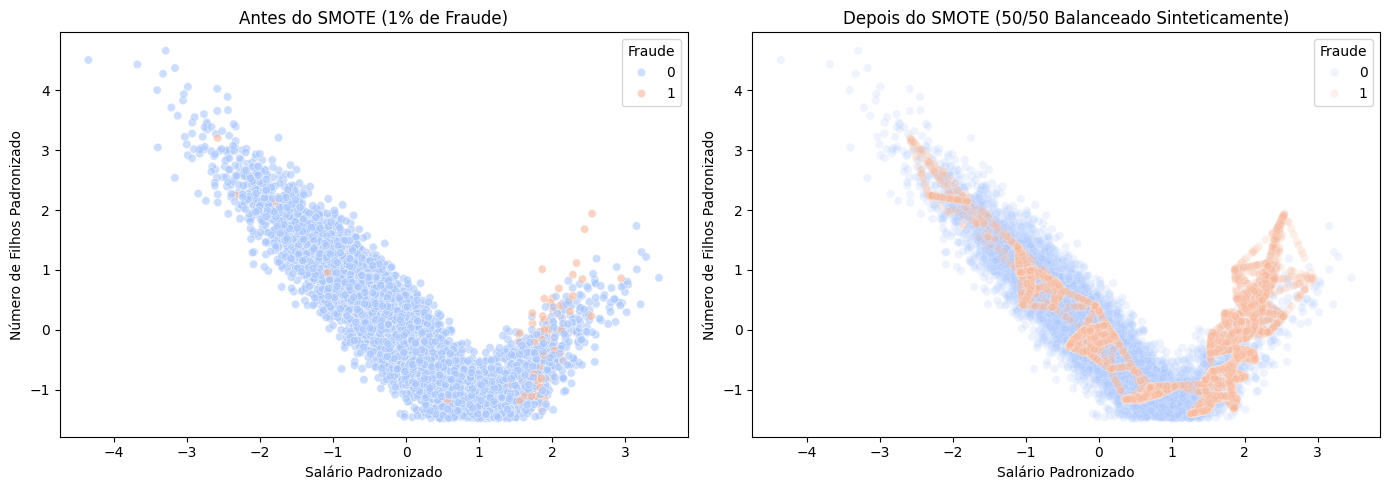

In [6]:
# O balanceador do SMOTE também devolve arrays; convertendo para Pandas para plotar
X_treino_bal_df = pd.DataFrame(X_treino_balanceado, columns=['Salario', 'Num_Filhos'])
y_treino_bal_series = pd.Series(y_treino_balanceado, name="Fraude")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Antes do SMOTE (População Rara)
sns.scatterplot(x=X_treino_scaled_df['Salario'], y=X_treino_scaled_df['Num_Filhos'], 
                hue=y_treino.reset_index(drop=True), palette='coolwarm', alpha=0.6, ax=ax[0])
ax[0].set_title('Antes do SMOTE (1% de Fraude)')
ax[0].set_xlabel('Salário Padronizado')
ax[0].set_ylabel('Número de Filhos Padronizado')

# Gráfico 2: Depois do SMOTE (População Balanceada)
sns.scatterplot(x=X_treino_bal_df['Salario'], y=X_treino_bal_df['Num_Filhos'], 
                hue=y_treino_bal_series, palette='coolwarm', alpha=0.2, ax=ax[1])
ax[1].set_title('Depois do SMOTE (50/50 Balanceado Sinteticamente)')
ax[1].set_xlabel('Salário Padronizado')
ax[1].set_ylabel('Número de Filhos Padronizado')

plt.tight_layout()
plt.show()

**Perfeito!** Nossas classes agora estão equilibradas rigorosamente (50% / 50%) para o treinamento do modelo.  
Com escalas regularizadas e dados devidamente balanceados de forma sintética (sem *data leakage*), finalizamos o preparo da base artificial e encerramos este primeiro passo ilustrativo!\

---
## 🚀 Desafio Prático: Fraud Detection no Mundo Real (Kaggle)

Até agora, trabalhamos com uma base sintética perfeitamente comportada. Mas no mundo real, as transações de cartão de crédito são altamente nebulosas. O dataset [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) do Kaggle possui 284.807 transações da Europa, onde apenas **492 são fraudes** (0.172%).

Seu desafio é aplicar o que aprendemos numa base real:
1. Faça o download do arquivo `creditcard.csv` no Kaggle.
2. Carregue o CSV num novo `DataFrame` pandas e vizualize o desbalanceamento brutal da classe `Class`.
3. Separe o `X` (Features de V1 até V28, e a coluna `Amount`) do nosso alvo `y` (`Class`).
4. **Aplique o Split Seguro (Train Test Split)**!
5. Importante: Diferente das features PCA (V1 a V28), a feature `Amount` da base original contém valores financeiros brutos. Aplique o `StandardScaler` **APENAS no Treino**, mas lembre-se de transformar o **Teste** com esta mesma régua.
6. A base de treino desbalanceada terá mais de 200 mil transações normais e meras 350 fraudes. Salve o dia usando `SMOTE(random_state=42)` no Treino!\

In [7]:
import pandas as pd
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1. Download do dataset e definição da variável 'path'
path = kagglehub.dataset_download("saurabhbadole/credit-card-dataset")
print("Caminho do dataset:", path)

# 2. Carregar os dados (usando a variável path definida acima)
# O arquivo costuma estar direto na pasta ou em uma subpasta 'creditcard.csv'
df_kaggle = pd.read_csv(f"{path}/creditcard.csv")

# 3. Split X e y
# 'Class' é o alvo: 0 para normal, 1 para fraude [cite: 110, 154, 155]
X = df_kaggle.drop('Class', axis=1)
y = df_kaggle['Class']

# 4. train_test_split (A Regra de Ouro: Separar antes de processar) [cite: 68, 78, 84]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Escalonamento (Nivelando o campo) [cite: 40, 58]
scaler = StandardScaler()
# Aprendemos a média/desvio apenas no TREINO [cite: 71, 75, 88]
X_train_scaled = scaler.fit_transform(X_train)
# Aplicamos a mesma régua no TESTE (sem aprender de novo) [cite: 73, 77, 101]
X_test_scaled = scaler.transform(X_test)

# 6. Aplique o SMOTE (Balanceamento da classe minoritária) [cite: 117, 121]
# O SMOTE cria dados sintéticos interpolando vizinhos [cite: 123, 133]
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# Validação final do balanceamento [cite: 152, 153]
print("\nVerificação de Classes no Treino (Pós-SMOTE):")
print(y_train_res.value_counts())

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Caminho do dataset: /Users/luigiajello/.cache/kagglehub/datasets/saurabhbadole/credit-card-dataset/versions/1



Verificação de Classes no Treino (Pós-SMOTE):
Class
0    227451
1    227451
Name: count, dtype: int64


---
## 🧠 Questão Discursiva

**Pergunta:** Qual seria o impacto técnico (e de negócio) se aplicássemos o algoritmo SMOTE no conjunto *inteiro* de dados, gerando as fraudes sintéticas **ANTES** de aplicar o método de separação `train_test_split()`? 

Em sua resposta, explique o conceito de **Data Leakage (Vazamento de Dados)** e justifique por que o conjunto de TESTE deve permanecer "imaculado".\

**SUA RESPOSTA AQUI:**
*Aplicar o SMOTE antes da separação causa Vazamento de Dados. O algoritmo cria fraudes artificiais usando informações que deveriam ser exclusivas do teste, gerando um overfitting mascarado. O modelo parece perfeito nos relatórios, mas falha ao enfrentar dados reais.Para o negócio, isso traz uma falsa sensação de segurança. O modelo terá um desempenho excelente no laboratório, mas deixará passar fraudes reais na prática, causando prejuízos financeiros. O conjunto de teste deve ficar imaculado para simular o "mundo real", onde os dados são desconhecidos e desbalanceados*
\